```28/07/2025 - Gabriel A. Amici```

# Implementando classes para a biblioteca ```emerald```

### Objetivos:
- Compactar código
- Reutilizar rotinas similares
- Facilitar uso da biblioteca

### Classes base:
- ```Potential```
- ```Field```
- ```Particle```
- ```System```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq


In [2]:
# to be added to its own module later

from scipy.special import roots_legendre


def gauss_legendre_quadrature(func: callable, a: float, b: float, N: int) -> float:
    """
    Gauss-Legendre Quadrature for numerical integration.

    Parameters:
    func : callable
        The function to integrate.
    a : float
        The lower limit of integration.
    b : float
        The upper limit of integration.
    N : int
        The number of quadrature points (degree of the Legendre polynomial).
    """

    # Compute the roots and weights for the N-th degree Legendre polynomial
    roots, weights = roots_legendre(N)
    
    # Transform the roots to the interval [a, b]
    transformed_roots = 0.5 * (b - a) * roots + 0.5 * (b + a)
    
    # Evaluate the function at the transformed roots
    func_values = func(transformed_roots)
    
    # Compute the quadrature result
    result = 0.5 * (b - a) * np.dot(weights, func_values)
    
    return result

def simpson13(func: callable, a: float, b: float, dx: float = 1.e-5):
    """
    General Simpson 1/3 quadrature for callable `func`

    Parameters:
        func : callable
            The function to integrate.
        a : float
            The lower limit of integration.
        b : float
            The upper limit of integration.
        dx : int
            The extent of each interval.
    """
    n = round((b - a) / dx)
    n += 1 if (n % 2 != 0) else 0

    if n % 2 != 0:
        raise ValueError(
            "Simpson's 1/3 rule requires an even number of intervals."
        )

    # x = a + np.arange(n + 1) * dx
    # x = np.arange(a, b+dx, dx)
    x = np.linspace(a, b, n)
    y = func(x)

    return (dx / 3) * (
        y[0]
        + y[-1]
        + 4 * np.sum(y[1:-1:2])
        + 2 * np.sum(y[2:-1:2])
    )

In [3]:
def f(x):
    return x**2

simpson13(f, -1, 1, dx=0.01) # gauss_legendre_quadrature(f, -1, 1, 2)

0.6600335008375211

In [62]:
from abc import ABC, abstractmethod


class Potential(ABC):
    """
    Base class for 1D potentials, responsible for calculating the potential 
    and its derivatives, as well as the classical return points.
    """

    def __init__(self, *args, **kwargs):
        self.name    = kwargs.get('name') if 'name' in kwargs else None
        self.acronym = kwargs.get('acronym') if 'acronym' in kwargs else None
        self.symmetric = self._check_symmetry()

    @abstractmethod
    def value(self, position_array):
        """
        Potential evaluated at a range of positions

        Parameters
        ----------
        position_array : array-like
            Array of positions at which to evaluate the potential

        Returns
        -------
        potential_values : array-like
            Array of potential values corresponding to the input positions
        """
        r = np.asarray(position_array)
        pass

    @abstractmethod
    def first_derivative(self, position_array):
        """
        1st derivative of the potential evaluated for a range of positions

        Parameters
        ----------
        position_array : array-like
            Array of positions at which to evaluate the derivative

        Returns
        -------
        first_derivative_values : array-like
            Array of first derivative values corresponding to the input positions
        """
        r = np.asarray(position_array)
        pass

    @abstractmethod
    def second_derivative(self, position_array):
        """
        2nd derivative of the potential evaluated for a range of positions

        Parameters
        ----------
        position_array : array-like
            Array of positions at which to evaluate the second derivative

        Returns
        -------
        second_derivative_values : array-like
            Array of second derivative values corresponding to the input positions
        """
        r = np.asarray(position_array)

    def _check_symmetry(self):
        """
        Check if the potential is symmetric around the origin

        Returns
        -------
        bool
            True if the potential is symmetric, False otherwise
        """
        r = np.random.uniform(1e-5, 2, 100)  # Random small distance from the origin
        return np.allclose(self.value(r), self.value(-r))
    
    def return_points(self, E: float = 0.0, a: float = -10.0, b: float = 10.0):
        """
        Classical return points of the potential
        
        General implementation finds the return points numerically by solving V(r) = E for a given energy E.
        """

        fn = lambda r: self.value(r) - E

        # Find the return points by solving V(r) = E
        r1 = brentq(fn, a, 0)  # Left return
        r2 = brentq(fn, 0, b)   # Right return

        return r1, r2

    def momentum(self, E: float, r: np.ndarray | float):
        """
        Classical momentum of the particle in the potential at a given
        position and energy.
        """
        r = np.asarray(r)
        radicand = 2 * (E - self.value(r))
        mask = (radicand < 0) & np.isclose(radicand, 0, atol=1e-8)
        radicand = np.where(mask, 0, radicand)

        return np.sqrt(radicand)

    def action(self, E: float, N: int = 2000, dr: float = 1.e-6):
        """
        Classical action of the particle in the potential at a given energy

        Parameters
        ----------
        E : float
            Energy of the particle
        a : float, optional
            Lower limit for finding return points, by default -10.0
        b : float, optional
            Upper limit for finding return points, by default 10.0
        N : int, optional
            Number of quadrature points for numerical integration, by default 2000
        """

        r1, r2 = self.return_points(E)
        if None in (r1, r2):
            raise ValueError(f"Return points not found for energy E={E}.")
        if self.symmetric:
            # action = 2 * gauss_legendre_quadrature(lambda r: self.momentum(E, r), 0, r2, N) / np.pi
            action = 2 * simpson13(lambda r: self.momentum(E, r), r1, r2, dr) / np.pi
            return action
        
        # action = gauss_legendre_quadrature(lambda r: self.momentum(E, r), r1, r2, N) / np.pi
        action = simpson13(lambda r: self.momentum(E, r), r1, r2, dr) / np.pi
        return action

    def angular_frequency(self, E: float, dE: float = 1e-5, N: int = 2000):
        """
        Classical angular frequency of the particle in the potential at a given energy

        Parameters
        ----------
        E : float
            Energy of the particle
        N : int, optional
            Number of quadrature points for numerical integration, by default 2000
        """
        return ( (1/(12*dE))*( self.action(E-2*dE, N)  
                                  - 8*self.action(E-dE, N ) 
                                  + 8*self.action(E+dE, N ) 
                                  - self.action(E+2*dE, N ) )
                                  )**(-1)

    def angle(self, E: float, r: np.ndarray | float, dr: float = 1.e-5):
        """
        Calculates the canonycal angle, the dynamical variable whose
        conjugate is the action.
        """

        r = np.asarray(r)

        rm, _ = self.return_points(E)
        freq = self.angular_frequency(E)

        # integrand = lambda x: ( 2*(E - self.value(x)) )**(-1/2)

        if r.size == 1:
            # return freq*simpson13(integrand, rm, r, dr)
            return freq*gauss_legendre_quadrature(lambda x: 1/self.momentum(E, x), rm, r, 3000)

    @staticmethod
    def _grid(lo: float, hi: float, N: int = None, dr: float = None) -> np.ndarray:
        """Build a spatial grid from either a point count or a resolution — never both."""
        if (N is None) == (dr is None):
            raise ValueError("Specify exactly one of N or dr.")
        if N is not None:
            return np.linspace(lo, hi, N)
        n = max(int(round((hi - lo) / dr)) + 1, 2)
        return np.linspace(lo, hi, n)   # linspace, not arange, to hit `hi` exactly
        
    def phase_space(self, E: float, N: int = None, dr: float = None,
                     r1: float = None, r2: float = None, output: str = "rp"):
        """
        Phase space portrait of a particle of energy E under this potential.
    
        r1, r2 are only used as fallback plotting limits on a side where the
        potential is unbound at this energy (return_points gives None there) —
        they're ignored on any side that has a genuine return point.
        """
        rm, rM = self.return_points(E)
    
        if rm is not None and rM is not None:
            # bound: both edges are real turning points -> full closed orbit
            r = self._grid(rm, rM, N, dr)
            p = self.momentum(E, r)
            p[0], p[-1] = 0.0, 0.0                      # clamp: exact zero at true turning points
            r_out = np.concatenate([r, r[::-1]])
            p_out = np.concatenate([p, -p[::-1]])
    
        elif rm is not None:                             # unbound above: only rm is real
            if r2 is None:
                raise ValueError("Unbound above at this energy — supply r2.")
            r = self._grid(rm, r2, N, dr)
            p = self.momentum(E, r)
            p[0] = 0.0
            # incoming branch first: puts the seam (rm, real) in the middle,
            # leaves the artificial edge r2 at the two loose ends
            r_out = np.concatenate([r[::-1], r])
            p_out = np.concatenate([-p[::-1], p])
    
        elif rM is not None:                             # unbound below: only rM is real
            if r1 is None:
                raise ValueError("Unbound below at this energy — supply r1.")
            r = self._grid(r1, rM, N, dr)
            p = self.momentum(E, r)
            p[-1] = 0.0
            r_out = np.concatenate([r, r[::-1]])
            p_out = np.concatenate([p, -p[::-1]])
    
        else:                                             # fully unbound: no fold at all
            if r1 is None or r2 is None:
                raise ValueError("No return points at this energy — supply r1 and r2.")
            r_out = self._grid(r1, r2, N, dr)
            p_out = self.momentum(E, r_out)

        if output in "rp":
            return {"rp": (r_out, p_out), "r": r_out, "p": p_out}[output]
            

A partir da classe base é possível implementar potenciais como classes herdadas:

In [52]:
class MorseSoftCoulomb(Potential):
    """
    Morse-soft-Coulomb potential (MsC) is a 1D soft potential with a Morse 
    barrier at the origin. The parameter 'alpha' controls the well depth and
    barrier hardness.
    """
    
    def __init__(self, alpha: float):
        self.alpha      = alpha
        self.well_depth = 1 / alpha
        self.beta       = 1 / (alpha * np.sqrt(2))
        self.name       = "Morse-soft-Coulomb"
        self.acronym    = "MsC"
        super().__init__(name=self.name, acronym=self.acronym)
    
    def value(self, position_array):
        r = np.asarray(position_array)
        
        coulomb = -1 / np.sqrt(r**2 + self.alpha**2)
        morse = self.well_depth * (np.exp(-2 * self.beta * r) - 2 * np.exp(-self.beta * r))
        
        return np.where(r > 0, coulomb, morse)
    
    def first_derivative(self, position_array):
        r = np.asarray(position_array)
        
        coulomb = r*(r**2 + self.alpha**2)**(-3/2)
        morse = 2*self.well_depth*self.beta*np.exp( -2*self.beta*r)*( np.exp( self.beta*r ) - 1 )
        
        return np.where(r > 0, coulomb, morse)
    
    def second_derivative(self, position_array):
        r = np.asarray(position_array)
        
        coulomb = (r**2 + self.alpha**2)**(-3/2) - 3*r**2*(r**2 + self.alpha**2)**(-5/2)
        morse = 4*self.well_depth*self.beta**2*np.exp( -2*self.beta*r )*( np.exp( self.beta*r ) - 0.5 )
        
        return np.where(r > 0, coulomb, morse)
    
    def return_points(self, energy: float = 0.):
        
        if energy < -self.well_depth:
            raise Warning(f"Energy must be greater than the well depth ({-self.well_depth})")
            return (None, None) 

        rm = -self.alpha*np.sqrt(2)*np.log( np.sqrt( self.alpha*energy + 1 ) + 1 )
        rM = np.sqrt( 1/(energy**2) - self.alpha**2 )
        
        if energy >= 0:
            return rm, None
        else:
            return rm, rM

In [53]:
msc = MorseSoftCoulomb(alpha=0.1)

In [7]:
msc.symmetric

False

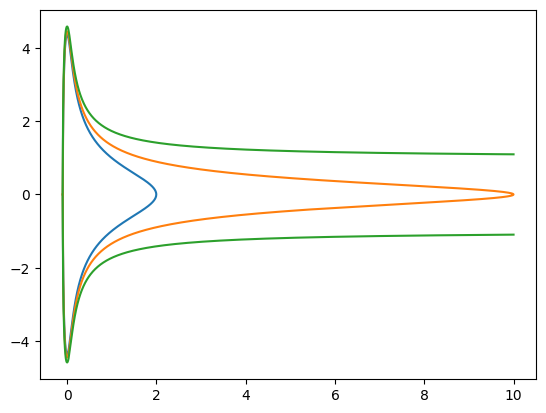

In [61]:
f = lambda x: msc.momentum(-0.5, x)
r1, r2 = msc.return_points(-0.5)
# simpson13(f, r1, r2)
# msc.action(-0.5, dr=1.e-7)
# r1, r2

r, p = msc.phase_space(-0.5, 1000)

plt.plot(*msc.phase_space(-0.5, 1000))
plt.plot(*msc.phase_space(-0.1, 1000))
plt.plot(*msc.phase_space(0.5, 1000, r2=10))
# plt.plot(r, -p)

In [9]:
r = np.arange(r1, r2+1.e-6, 1.e-6)

np.isnan(f(r))
# r[-1]

/tmp/ipykernel_33127/2450723031.py:105: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(radicand)


array([False, False, False, ..., False, False,  True])

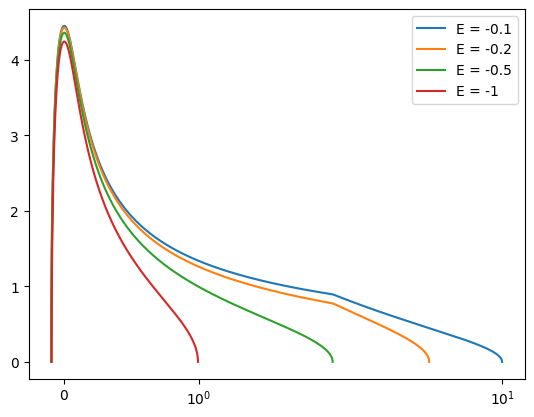

In [10]:
for E in [-0.1, -0.2, -0.5, -1]:
    r1, r2 = msc.return_points(E)
    r = np.linspace(r1, r2, 10000)
    p = msc.momentum(E, r)

    plt.plot(r, p, label=f"E = {E}")
plt.xscale('symlog')
plt.legend()
plt.show()

In [37]:
r1, r2 = msc.return_points(-0.5)
msc.angle(-0.5, r2, dr=1.e-5)

3.1764184571771548

In [12]:
f = lambda x: freq/msc.momentum(-0.5, x)
freq = msc.angular_frequency(-0.5)

print(simpson13(f, r1, 0, dx=1.e-7))
print(gauss_legendre_quadrature(f, r1, 0, 2000))


0.4861046042689188
0.03173070129517213


In [13]:
# for N in range(10, 500, 10):
#     print(f"N = {N:4d}, J = {msc.action(E=-0.5, N=N):.10f}")
N = 2000
print(f"N = {N:4d}, J = {msc.action(E=-0.5, N=N):.10f}")

N = 2000, J = 0.9362186495


In [14]:
# for dE in [1e-4, 1e-5, 1e-6, 1e-7, 1e-8]:
#     print(f"dE = {dE:.0e}, w = {msc.angular_frequency(E=-0.5, dE=dE, N=2000):.10f}")
msc.angular_frequency(E=-0.5, dE=1e-6, N=2000)

0.9877846150647885

In [15]:
from scipy.misc import derivative

In [26]:
f = lambda E: msc.action(E, N=2000)

derivative(f, -0.5, dx=1e-9)**(-1)

/tmp/ipykernel_33127/706885220.py:3: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  derivative(f, -0.5, dx=1e-9)**(-1)


-1.2882296437353646

In [39]:
from emerald.classical.msc_unperturbed import MsC_angular_frequency, MsC_action, MsC_angle

In [44]:
rm, rM = msc.return_points(-0.5)
omega_n = MsC_angular_frequency(0.1, -0.5)
print(omega_n)
MsC_angle(0.1, -0.5, rM, omega_n, dr=1.e-8)

0.9840289286066356


3.141381305134808

In [19]:
(rM - rm)/1.e-6

2093722.3852536678

In [20]:
MsC_angular_frequency(alpha=0.01, E=-0.5, dE=1e-6)

0.9994853853154522

In [21]:
for dr in [1.e-3, 1.e-4, 1.e-5, 1.e-6, 1.e-7, 1.e-8, 1.e-9]:
    print(f"dr = {dr:.0e}, J = {MsC_action(alpha=0.01, E=-0.5, dr=dr):.10f}")
# for N in range(500, 2000, 100):
    print(f"N = {N:4d}, J = {msc.action(E=-0.5, N=N):.10f}")

dr = 1e-03, J = 0.9819415111
N = 2000, J = 0.9362186495
dr = 1e-04, J = 0.9821389315
N = 2000, J = 0.9362186495
dr = 1e-05, J = 0.9821450765
N = 2000, J = 0.9362186495
dr = 1e-06, J = 0.9821452741
N = 2000, J = 0.9362186495
dr = 1e-07, J = 0.9821452803
N = 2000, J = 0.9362186495
dr = 1e-08, J = 0.9821452805
N = 2000, J = 0.9362186495
dr = 1e-09, J = 0.9821452805
N = 2000, J = 0.9362186495


In [22]:
dr = 1.e-7 ; print(f"dr = {dr:.0e}, J = {MsC_action(alpha=0.01, E=-0.5, dr=dr):.10f}") # 0.0s
N = 2000   ; print(f"N = {N:4d}, J = {msc.action(E=-0.5, N=N):.10f}") # 0.05s


dr = 1e-07, J = 0.9821452803
N = 2000, J = 0.9362186495


In [23]:
import matplotlib.pyplot as plt

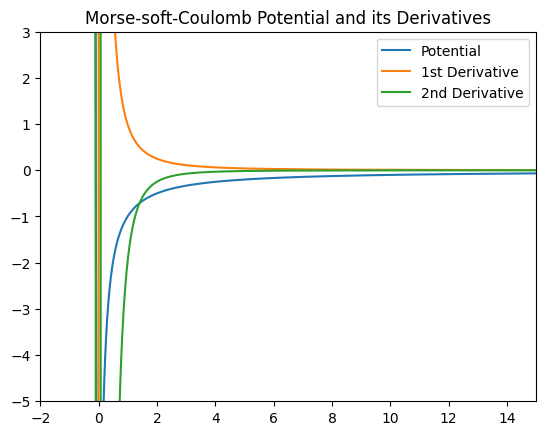

In [24]:
r = np.linspace(-2, 15, 1000)

plt.title(f"{msc.name} Potential and its Derivatives")
plt.plot(r, msc.value(r), label='Potential')
plt.plot(r, msc.first_derivative(r), label='1st Derivative')
plt.plot(r, msc.second_derivative(r), label='2nd Derivative')
plt.xlim(-2, 15)
plt.ylim(-5, 3)
plt.legend()
plt.show()